In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Разведочный анализ данных для датасета полученного путём парсинга [hirehi.ru](https://hirehi.ru/?category=analytics).

In [2]:
palette = ["#1f2d3a", "#0f766e", "#2a4d69", "#787b7e"]

### Первичный анализ и обработка данных

In [3]:
data = pd.read_csv("hirehi_vacancys.csv", index_col=0)

#### Обработка основной части датасета

In [4]:
data.isna().sum()

id           0
title        0
category     0
company      0
format       0
level        0
salary      46
link         0
skills       0
dtype: int64

<center><strong>Заметим, что пропуски у нас есть только в столбце "salary"</br>
Попозже разберемся как их заполнить</strong></center>

In [5]:
data.duplicated().sum()

np.int64(0)

<center><strong>дубликатов нет, хорошо</strong></center>

In [6]:
data["category"].value_counts()

category
development    3612
analytics      1325
management     1116
qa              914
design          753
devops          596
marketing       438
Name: count, dtype: int64

Видим 7 категорий в "category"

<center><h2><strong>1) Займемся обработкой "salary"</strong></h2></center> </br>Знаем, что есть 46 пропусков, на первый взгляд видим, что есть данные в таких форматах 'от 350 000 ₽', '~ 223 000 ₽', 'от 220 000 до 268 000 ₽', 'от 180 до 220 ₽'. Для начала оставим только цифры, а также посмотрим, есть ли в наших данных зарплаты в долларах.</strong></h4> 

In [7]:
data["salary"].unique().tolist()

['от 240 000 ₽',
 'от 350 000 ₽',
 '~ 372 000 ₽',
 '~ 223 000 ₽',
 '~ 210 000 ₽',
 '~ 345 000 ₽',
 'от 90 000 ₽',
 'от 320 000 ₽',
 '~ 65 000 ₽',
 '~ 282 000 ₽',
 '~ 386 000 ₽',
 '80 000 ₽',
 'зп не указана',
 '~ 371 000 ₽',
 '~ 318 000 ₽',
 'от 180 000 ₽',
 '~ 204 000 ₽',
 '~ 220 000 ₽',
 'от 160 000 ₽',
 '40 000 ₽',
 '~ 215 000 ₽',
 '~ 395 000 ₽',
 '~ 320 000 ₽',
 '~ 411 000 ₽',
 '~ 409 000 ₽',
 '~ 227 000 ₽',
 '240 000 ₽',
 '~ 68 000 ₽',
 '~ 325 000 ₽',
 '~ 265 000 ₽',
 'от 192 000 ₽',
 '~ 393 000 ₽',
 '~ 226 000 ₽',
 '~ 381 000 ₽',
 '~ 387 000 ₽',
 '~ 172 000 ₽',
 '~ 82 000 ₽',
 '~ 410 000 ₽',
 '~ 168 000 ₽',
 '~ 231 000 ₽',
 '~ 200 000 ₽',
 '~ 110 000 ₽',
 '~ 211 000 ₽',
 '~ 294 000 ₽',
 'от 150 000 ₽',
 '~ 80 000 ₽',
 '~ 91 000 ₽',
 'от 20 000 ₽',
 'от 250 000 ₽',
 '~ 347 000 ₽',
 '250 000 ₽',
 'от 65 000 ₽',
 'от 300 000 ₽',
 '~ 251 000 ₽',
 '~ 328 000 ₽',
 '~ 66 000 ₽',
 '~ 189 000 ₽',
 '~ 258 000 ₽',
 '~ 183 000 ₽',
 '~ 67 000 ₽',
 '~ 240 000 ₽',
 '~ 72 000 ₽',
 '~ 62 000 ₽',


Посмотрим есть ли у нас доллары(их нет), почти все строки в рублях

In [8]:
dollarorruble = data["salary"].str.contains(r"\$|₽").sum()
dollarorruble

np.int64(8488)

Знаем, что у нас 8754 строки, 8488 строк с рублями, тогда что в оставшихся 266 строках? 

In [9]:
not_dollarorruble = data["salary"].str.contains(r"\$|₽") == False

Посмотрим что в тех строках, где не доллар и не рубль

In [10]:
data[not_dollarorruble]["salary"].unique()

<StringArray>
['зп не указана', nan, 'зп не указана ', 'не оплачивается']
Length: 4, dtype: str

Видим, что оставшиеся ячейки это либо пропуски, либо зарплата не указана явно, можно приравнять эти строки к пропускам, чтобы потом заполнить их по общему правилу. 

In [11]:
data["salary"] = data["salary"].replace(
    ["зп не указана", "зп не указана ", "не оплачивается"], np.nan
)
data["salary"].isna().sum()

np.int64(266)

теперь получили 266 пропусков в столбце salary, вернемся к ним позже, пока займемся приведением зарплат к числам.
Нужно как-то склеить тысячи, чтобы при последующей замене на пробелы всего, кроме цифр, вилки не склеились в одно целое.

In [12]:
data["salary"] = data["salary"].str.replace(r"[^\d]", " ", regex=True).str.strip()

Удалили все, кроме цифр

In [13]:
data

,id,title,category,company,format,level,salary,link,skills
0,36700,quality assurance (manual),qa,NDA,удалённо по РФ,senior,240 000,https://hirehi.ru/qa/quality-assurance-manual-...,"['qa', 'manual testing', 'test automation', 'a..."
1,36699,iOS разработчик,development,Экосистема тенниса,удалённо,senior,350 000,https://hirehi.ru/development/ios-razrabotchik...,"['swift', 'uikit', 'xcode', 'storyboard', 'gcd..."
2,36697,platform engineer,devops,NDA,удалённо,senior,372 000,https://hirehi.ru/devops/platform-engineer-36697,"['gardenlinux', 'linux', 'kvm', 'qemu', 'libvi..."
3,36696,growth marketing manager,marketing,NDA,удалённо,middle,223 000,https://hirehi.ru/marketing/growth-marketing-m...,"['monetization', 'ltv', 'ab testing', 'b2c', '..."
4,36695,Бизнес аналитик,analytics,ВТБ,гибрид Москва,middle,210 000,https://hirehi.ru/analytics/biznes-analitik-36695,"['аналитика', 'бизнес-планирование', 'экономик..."
...,...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,удалённо,middle,180 220,https://hirehi.ru/development/ml-engineer-24856,"['ml', 'python', 'fastapi', 'scikit-learn', 'x..."
8750,24838,Разработчик PHP,development,Системы документооборота,офис Казань,senior,150 000,https://hirehi.ru/development/razrabotchik-php...,"['php', 'postgresql', 'memcached', 'gearman', ..."
8751,24836,Проектный менеджер IT,management,Системы документооборота,офис Казан,junior,NaN,https://hirehi.ru/management/proektnyi-menedzh...,[]
8752,24787,Системный Аналитик,analytics,iStaff-IT,удалённо по РФ,senior,200 000 285 000,https://hirehi.ru/analytics/sistemnyi-analitik...,"['sql', 'kafka', 'json', 'bpmn', 'uml', 'rest'..."


там, где мы заменили буквы, осталось несколько пробелов, пожэтому заменим их на один, а единственный между тысячами("000") в вилках уберем. Но чтобы нужные пробелы не удалились, заменим их на временные разделители, которые потом тоже удалим.</br>Чтобы понять, как обнаруживать два и более пробелов подряд, использовал эту <a href = "https://habr.com/ru/articles/349860/">статью</a>

In [14]:
data["salary"] = data["salary"].str.replace(r"\s{2,}", "*", regex=True)
data

,id,title,category,company,format,level,salary,link,skills
0,36700,quality assurance (manual),qa,NDA,удалённо по РФ,senior,240 000,https://hirehi.ru/qa/quality-assurance-manual-...,"['qa', 'manual testing', 'test automation', 'a..."
1,36699,iOS разработчик,development,Экосистема тенниса,удалённо,senior,350 000,https://hirehi.ru/development/ios-razrabotchik...,"['swift', 'uikit', 'xcode', 'storyboard', 'gcd..."
2,36697,platform engineer,devops,NDA,удалённо,senior,372 000,https://hirehi.ru/devops/platform-engineer-36697,"['gardenlinux', 'linux', 'kvm', 'qemu', 'libvi..."
3,36696,growth marketing manager,marketing,NDA,удалённо,middle,223 000,https://hirehi.ru/marketing/growth-marketing-m...,"['monetization', 'ltv', 'ab testing', 'b2c', '..."
4,36695,Бизнес аналитик,analytics,ВТБ,гибрид Москва,middle,210 000,https://hirehi.ru/analytics/biznes-analitik-36695,"['аналитика', 'бизнес-планирование', 'экономик..."
...,...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,удалённо,middle,180*220,https://hirehi.ru/development/ml-engineer-24856,"['ml', 'python', 'fastapi', 'scikit-learn', 'x..."
8750,24838,Разработчик PHP,development,Системы документооборота,офис Казань,senior,150 000,https://hirehi.ru/development/razrabotchik-php...,"['php', 'postgresql', 'memcached', 'gearman', ..."
8751,24836,Проектный менеджер IT,management,Системы документооборота,офис Казан,junior,NaN,https://hirehi.ru/management/proektnyi-menedzh...,[]
8752,24787,Системный Аналитик,analytics,iStaff-IT,удалённо по РФ,senior,200 000*285 000,https://hirehi.ru/analytics/sistemnyi-analitik...,"['sql', 'kafka', 'json', 'bpmn', 'uml', 'rest'..."


заменим двойные и больше пробелы на "*", чтобы не склеилось все, дальше удалим одиночные пробелы.

In [15]:
data["salary"] = data["salary"].str.replace(r"\s", "", regex=True)
data

,id,title,category,company,format,level,salary,link,skills
0,36700,quality assurance (manual),qa,NDA,удалённо по РФ,senior,240000,https://hirehi.ru/qa/quality-assurance-manual-...,"['qa', 'manual testing', 'test automation', 'a..."
1,36699,iOS разработчик,development,Экосистема тенниса,удалённо,senior,350000,https://hirehi.ru/development/ios-razrabotchik...,"['swift', 'uikit', 'xcode', 'storyboard', 'gcd..."
2,36697,platform engineer,devops,NDA,удалённо,senior,372000,https://hirehi.ru/devops/platform-engineer-36697,"['gardenlinux', 'linux', 'kvm', 'qemu', 'libvi..."
3,36696,growth marketing manager,marketing,NDA,удалённо,middle,223000,https://hirehi.ru/marketing/growth-marketing-m...,"['monetization', 'ltv', 'ab testing', 'b2c', '..."
4,36695,Бизнес аналитик,analytics,ВТБ,гибрид Москва,middle,210000,https://hirehi.ru/analytics/biznes-analitik-36695,"['аналитика', 'бизнес-планирование', 'экономик..."
...,...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,удалённо,middle,180*220,https://hirehi.ru/development/ml-engineer-24856,"['ml', 'python', 'fastapi', 'scikit-learn', 'x..."
8750,24838,Разработчик PHP,development,Системы документооборота,офис Казань,senior,150000,https://hirehi.ru/development/razrabotchik-php...,"['php', 'postgresql', 'memcached', 'gearman', ..."
8751,24836,Проектный менеджер IT,management,Системы документооборота,офис Казан,junior,NaN,https://hirehi.ru/management/proektnyi-menedzh...,[]
8752,24787,Системный Аналитик,analytics,iStaff-IT,удалённо по РФ,senior,200000*285000,https://hirehi.ru/analytics/sistemnyi-analitik...,"['sql', 'kafka', 'json', 'bpmn', 'uml', 'rest'..."


Удаляем звездочку и заменяем ее на пробел

In [16]:
data["salary"] = data["salary"].str.replace("*", " ")
data

,id,title,category,company,format,level,salary,link,skills
0,36700,quality assurance (manual),qa,NDA,удалённо по РФ,senior,240000,https://hirehi.ru/qa/quality-assurance-manual-...,"['qa', 'manual testing', 'test automation', 'a..."
1,36699,iOS разработчик,development,Экосистема тенниса,удалённо,senior,350000,https://hirehi.ru/development/ios-razrabotchik...,"['swift', 'uikit', 'xcode', 'storyboard', 'gcd..."
2,36697,platform engineer,devops,NDA,удалённо,senior,372000,https://hirehi.ru/devops/platform-engineer-36697,"['gardenlinux', 'linux', 'kvm', 'qemu', 'libvi..."
3,36696,growth marketing manager,marketing,NDA,удалённо,middle,223000,https://hirehi.ru/marketing/growth-marketing-m...,"['monetization', 'ltv', 'ab testing', 'b2c', '..."
4,36695,Бизнес аналитик,analytics,ВТБ,гибрид Москва,middle,210000,https://hirehi.ru/analytics/biznes-analitik-36695,"['аналитика', 'бизнес-планирование', 'экономик..."
...,...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,удалённо,middle,180 220,https://hirehi.ru/development/ml-engineer-24856,"['ml', 'python', 'fastapi', 'scikit-learn', 'x..."
8750,24838,Разработчик PHP,development,Системы документооборота,офис Казань,senior,150000,https://hirehi.ru/development/razrabotchik-php...,"['php', 'postgresql', 'memcached', 'gearman', ..."
8751,24836,Проектный менеджер IT,management,Системы документооборота,офис Казан,junior,NaN,https://hirehi.ru/management/proektnyi-menedzh...,[]
8752,24787,Системный Аналитик,analytics,iStaff-IT,удалённо по РФ,senior,200000 285000,https://hirehi.ru/analytics/sistemnyi-analitik...,"['sql', 'kafka', 'json', 'bpmn', 'uml', 'rest'..."


На всякий случай еще раз обрежем края

In [17]:
data["salary"] = data["salary"].str.strip()
data

,id,title,category,company,format,level,salary,link,skills
0,36700,quality assurance (manual),qa,NDA,удалённо по РФ,senior,240000,https://hirehi.ru/qa/quality-assurance-manual-...,"['qa', 'manual testing', 'test automation', 'a..."
1,36699,iOS разработчик,development,Экосистема тенниса,удалённо,senior,350000,https://hirehi.ru/development/ios-razrabotchik...,"['swift', 'uikit', 'xcode', 'storyboard', 'gcd..."
2,36697,platform engineer,devops,NDA,удалённо,senior,372000,https://hirehi.ru/devops/platform-engineer-36697,"['gardenlinux', 'linux', 'kvm', 'qemu', 'libvi..."
3,36696,growth marketing manager,marketing,NDA,удалённо,middle,223000,https://hirehi.ru/marketing/growth-marketing-m...,"['monetization', 'ltv', 'ab testing', 'b2c', '..."
4,36695,Бизнес аналитик,analytics,ВТБ,гибрид Москва,middle,210000,https://hirehi.ru/analytics/biznes-analitik-36695,"['аналитика', 'бизнес-планирование', 'экономик..."
...,...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,удалённо,middle,180 220,https://hirehi.ru/development/ml-engineer-24856,"['ml', 'python', 'fastapi', 'scikit-learn', 'x..."
8750,24838,Разработчик PHP,development,Системы документооборота,офис Казань,senior,150000,https://hirehi.ru/development/razrabotchik-php...,"['php', 'postgresql', 'memcached', 'gearman', ..."
8751,24836,Проектный менеджер IT,management,Системы документооборота,офис Казан,junior,NaN,https://hirehi.ru/management/proektnyi-menedzh...,[]
8752,24787,Системный Аналитик,analytics,iStaff-IT,удалённо по РФ,senior,200000 285000,https://hirehi.ru/analytics/sistemnyi-analitik...,"['sql', 'kafka', 'json', 'bpmn', 'uml', 'rest'..."


Видим, что остались вилки, вместо них подставим среднее значение. Также умножим на 1000 те результаты, которые окажутся меньше 1000

In [18]:
def count_avg(i):
    fork = str(i).split()
    values = []
    for j in fork:
        values.append(float(j))
    if len(values) == 2:
        salary = (values[0] + values[1]) / 2
    elif len(values) == 1:
        salary = values[0]
    else:
        return np.nan

    if salary <= 1000:
        salary = salary * 1000

    return salary

Применим функцию к столбцу salary

In [19]:
data["salary"] = data["salary"].apply(count_avg)
data

,id,title,category,company,format,level,salary,link,skills
0,36700,quality assurance (manual),qa,NDA,удалённо по РФ,senior,240000.0,https://hirehi.ru/qa/quality-assurance-manual-...,"['qa', 'manual testing', 'test automation', 'a..."
1,36699,iOS разработчик,development,Экосистема тенниса,удалённо,senior,350000.0,https://hirehi.ru/development/ios-razrabotchik...,"['swift', 'uikit', 'xcode', 'storyboard', 'gcd..."
2,36697,platform engineer,devops,NDA,удалённо,senior,372000.0,https://hirehi.ru/devops/platform-engineer-36697,"['gardenlinux', 'linux', 'kvm', 'qemu', 'libvi..."
3,36696,growth marketing manager,marketing,NDA,удалённо,middle,223000.0,https://hirehi.ru/marketing/growth-marketing-m...,"['monetization', 'ltv', 'ab testing', 'b2c', '..."
4,36695,Бизнес аналитик,analytics,ВТБ,гибрид Москва,middle,210000.0,https://hirehi.ru/analytics/biznes-analitik-36695,"['аналитика', 'бизнес-планирование', 'экономик..."
...,...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,удалённо,middle,200000.0,https://hirehi.ru/development/ml-engineer-24856,"['ml', 'python', 'fastapi', 'scikit-learn', 'x..."
8750,24838,Разработчик PHP,development,Системы документооборота,офис Казань,senior,150000.0,https://hirehi.ru/development/razrabotchik-php...,"['php', 'postgresql', 'memcached', 'gearman', ..."
8751,24836,Проектный менеджер IT,management,Системы документооборота,офис Казан,junior,NaN,https://hirehi.ru/management/proektnyi-menedzh...,[]
8752,24787,Системный Аналитик,analytics,iStaff-IT,удалённо по РФ,senior,242500.0,https://hirehi.ru/analytics/sistemnyi-analitik...,"['sql', 'kafka', 'json', 'bpmn', 'uml', 'rest'..."


<h3><strong>Теперь заполним пропуски, для этого будем смотреть category и level и будем рассчитывать число для пропуска исходя из зарплат в этой категории и этого уровня.</strong></h3>

In [20]:
data["level"].value_counts()

level
middle        4235
senior        3089
lead           768
junior         468
intern         129
head            63
грейда нет       1
не указан        1
Name: count, dtype: int64

Так мы нашли что есть несколько грейдов:</br>
1) intern</br>
2) junior</br>
3) middle</br>
5) senior</br> 
5) lead</br>
5) head</br>

In [21]:
head = data["level"].str.contains("head")
data_head = data[head]
data_head

,id,title,category,company,format,level,salary,link,skills
720,35969,Tech lead,development,Аддамант,удалённо,head,360000.0,https://hirehi.ru/development/tech-lead-35969,[]
760,35926,head of marketing,marketing,NDA,удалённо,head,200000.0,https://hirehi.ru/marketing/head-of-marketing-...,"['маркетинг', 'performance', 'аналитика', 'бюд..."
979,35694,product designer,design,1inch,офис Дубай,head,595000.0,https://hirehi.ru/design/product-designer-35694,"['ux', 'ui', 'product design', 'design systems..."
1368,35280,директор по маркетингу,marketing,NDA,офис,head,376000.0,https://hirehi.ru/marketing/direktor-po-market...,"['маркетинг', 'стратегия', 'digital', 'аналити..."
1463,35180,cpo,management,Плати по миру,офис Москва,head,500000.0,https://hirehi.ru/management/cpo-35180,"['product management', 'custdev', 'a/b тесты',..."
...,...,...,...,...,...,...,...,...,...
7836,26835,cpo,management,Сбер,офис Москва,head,584300.0,https://hirehi.ru/management/cpo-26835,"['искусственный интеллект', 'product owner', '..."
8037,26544,cto,development,NDA,удалённо,head,791400.0,https://hirehi.ru/development/cto-26544,"['pixi.js', 'игровая разработка', 'управление ..."
8109,26425,product analyst,analytics,Sweed,удалённо,head,494600.0,https://hirehi.ru/analytics/product-analyst-26425,"['sql', 'bi tools', 'metabase', 'looker', 'mod..."
8674,25577,backend разработчик,development,Т-Банк,гибрид Москва,head,715300.0,https://hirehi.ru/development/backend-razrabot...,"['system design', 'backend', 'frontend', 'тимл..."


In [22]:
nograde = data["level"].str.contains("грейда нет")
data_nograde = data[nograde]
data_nograde

,id,title,category,company,format,level,salary,link,skills
2147,34417,AI Frontend Design Engineer,design,EGO digital,удалённо,грейда нет,240000.0,https://hirehi.ru/design/ai-frontend-design-en...,"['figma', 'v0 (vercel)', 'anthropic (claude', ..."


In [23]:
none = data["level"].str.contains("не указан")
data_none = data[none]
data_none

,id,title,category,company,format,level,salary,link,skills
6452,28919,разработчик 1c,development,topgo.group,гибрид Питер,не указан,150000.0,https://hirehi.ru/development/razrabotchik-1c-...,"['1с:предприятие 8.3', 'бухгалтерия предприяти..."


In [24]:
data["category"].value_counts()

category
development    3612
analytics      1325
management     1116
qa              914
design          753
devops          596
marketing       438
Name: count, dtype: int64

Нужно присвоить грейд двум вакансиям без грейда, для этого посмотрим на медианные значения зарплат в их категории.

In [25]:
categories = data.groupby(["category", "level"])["salary"].agg(["median"])
categories

median
category    level               
analytics   head        462000.0
            intern       65000.0
            junior      101650.0
            lead        360500.0
            middle      208200.0
            senior      282400.0
design      head        518900.0
            intern       50700.0
            junior       70000.0
            lead        314800.0
            middle      139000.0
            senior      274550.0
            грейда нет  240000.0
development head        606150.0
            intern       60000.0
            junior       80000.0
            lead        412200.0
            middle      224750.0
            senior      336000.0
            не указан   150000.0
devops      intern       53400.0
            junior       97000.0
            lead        411400.0
            middle      231150.0
            senior      343400.0
management  head        496850.0
            intern       67250.0
            junior       98300.0
            lead        388500.0
            middle      224450.0
            senior      339000.0
marketing   head        457100.0
            intern       58900.0
            junior       62350.0
            lead        328000.0
            middle      154900.0
            senior      256300.0
qa          head        519900.0
            intern       50700.0
            junior       81000.0
            lead        342200.0
            middle      194300.0
            senior      277750.0

In [26]:
withnonegrade = categories.loc[["design", "development"]]
withnonegrade

median
category    level               
design      head        518900.0
            intern       50700.0
            junior       70000.0
            lead        314800.0
            middle      139000.0
            senior      274550.0
            грейда нет  240000.0
development head        606150.0
            intern       60000.0
            junior       80000.0
            lead        412200.0
            middle      224750.0
            senior      336000.0
            не указан   150000.0

Видим, что вакансия в дизайне ближе к senior, а в разработке - к middle

In [27]:
data.loc[(data["category"] == "design") & (data["level"] == "грейда нет"), "level"] = (
    "senior"
)
data.loc[
    (data["category"] == "development") & (data["level"] == "не указан"), "level"
] = "middle"

In [28]:
data["level"].value_counts()

level
middle    4236
senior    3090
lead       768
junior     468
intern     129
head        63
Name: count, dtype: int64

Теперь у нас 6 категорий грейдов, теперь можем заполнить медианными значениями пропуски по зарплате, воспользуемся функцией <a href = "https://dfedorov.spb.ru/pandas/Понимание%20функции%20transform%20в%20Pandas.html">transform</a>  

In [29]:
data["salary"] = data["salary"].fillna(
    data.groupby(["category", "level"])["salary"].transform("median")
)
data.isna().sum()

id          0
title       0
category    0
company     0
format      0
level       0
salary      0
link        0
skills      0
dtype: int64

In [30]:
data

,id,title,category,company,format,level,salary,link,skills
0,36700,quality assurance (manual),qa,NDA,удалённо по РФ,senior,240000.0,https://hirehi.ru/qa/quality-assurance-manual-...,"['qa', 'manual testing', 'test automation', 'a..."
1,36699,iOS разработчик,development,Экосистема тенниса,удалённо,senior,350000.0,https://hirehi.ru/development/ios-razrabotchik...,"['swift', 'uikit', 'xcode', 'storyboard', 'gcd..."
2,36697,platform engineer,devops,NDA,удалённо,senior,372000.0,https://hirehi.ru/devops/platform-engineer-36697,"['gardenlinux', 'linux', 'kvm', 'qemu', 'libvi..."
3,36696,growth marketing manager,marketing,NDA,удалённо,middle,223000.0,https://hirehi.ru/marketing/growth-marketing-m...,"['monetization', 'ltv', 'ab testing', 'b2c', '..."
4,36695,Бизнес аналитик,analytics,ВТБ,гибрид Москва,middle,210000.0,https://hirehi.ru/analytics/biznes-analitik-36695,"['аналитика', 'бизнес-планирование', 'экономик..."
...,...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,удалённо,middle,200000.0,https://hirehi.ru/development/ml-engineer-24856,"['ml', 'python', 'fastapi', 'scikit-learn', 'x..."
8750,24838,Разработчик PHP,development,Системы документооборота,офис Казань,senior,150000.0,https://hirehi.ru/development/razrabotchik-php...,"['php', 'postgresql', 'memcached', 'gearman', ..."
8751,24836,Проектный менеджер IT,management,Системы документооборота,офис Казан,junior,98300.0,https://hirehi.ru/management/proektnyi-menedzh...,[]
8752,24787,Системный Аналитик,analytics,iStaff-IT,удалённо по РФ,senior,242500.0,https://hirehi.ru/analytics/sistemnyi-analitik...,"['sql', 'kafka', 'json', 'bpmn', 'uml', 'rest'..."


In [31]:
data["salary"] = data["salary"].astype(int)
data

,id,title,category,company,format,level,salary,link,skills
0,36700,quality assurance (manual),qa,NDA,удалённо по РФ,senior,240000,https://hirehi.ru/qa/quality-assurance-manual-...,"['qa', 'manual testing', 'test automation', 'a..."
1,36699,iOS разработчик,development,Экосистема тенниса,удалённо,senior,350000,https://hirehi.ru/development/ios-razrabotchik...,"['swift', 'uikit', 'xcode', 'storyboard', 'gcd..."
2,36697,platform engineer,devops,NDA,удалённо,senior,372000,https://hirehi.ru/devops/platform-engineer-36697,"['gardenlinux', 'linux', 'kvm', 'qemu', 'libvi..."
3,36696,growth marketing manager,marketing,NDA,удалённо,middle,223000,https://hirehi.ru/marketing/growth-marketing-m...,"['monetization', 'ltv', 'ab testing', 'b2c', '..."
4,36695,Бизнес аналитик,analytics,ВТБ,гибрид Москва,middle,210000,https://hirehi.ru/analytics/biznes-analitik-36695,"['аналитика', 'бизнес-планирование', 'экономик..."
...,...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,удалённо,middle,200000,https://hirehi.ru/development/ml-engineer-24856,"['ml', 'python', 'fastapi', 'scikit-learn', 'x..."
8750,24838,Разработчик PHP,development,Системы документооборота,офис Казань,senior,150000,https://hirehi.ru/development/razrabotchik-php...,"['php', 'postgresql', 'memcached', 'gearman', ..."
8751,24836,Проектный менеджер IT,management,Системы документооборота,офис Казан,junior,98300,https://hirehi.ru/management/proektnyi-menedzh...,[]
8752,24787,Системный Аналитик,analytics,iStaff-IT,удалённо по РФ,senior,242500,https://hirehi.ru/analytics/sistemnyi-analitik...,"['sql', 'kafka', 'json', 'bpmn', 'uml', 'rest'..."


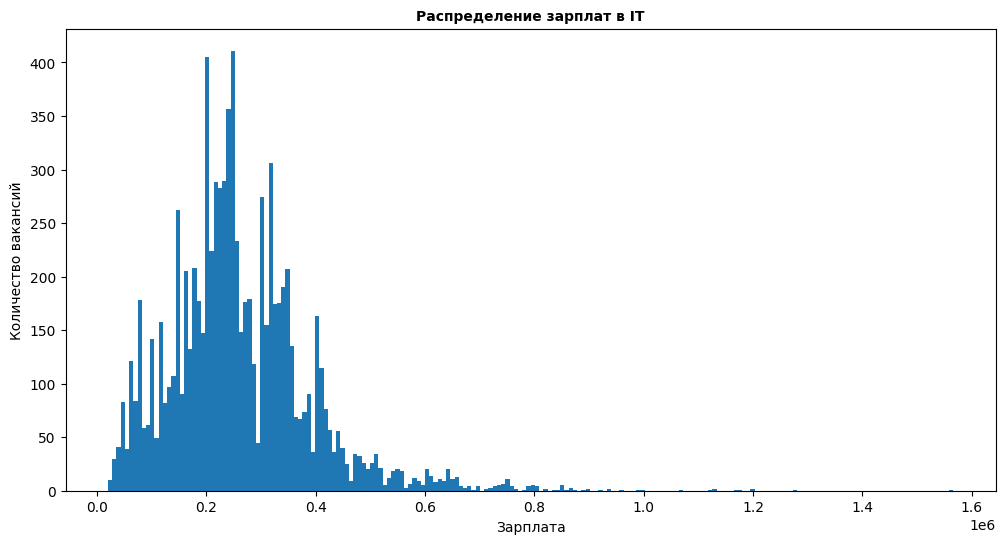

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.hist(data["salary"], bins=200)
plt.title("Распределение зарплат в IT", fontsize=10, fontweight="bold")
plt.xlabel("Зарплата")
plt.ylabel("Количество вакансий")
plt.show()

In [33]:
data["salary"].dropna().sort_values().tail(20)

7985     876700
4975     893400
1362     900000
524      900000
2913     919700
5879     933333
8648     936500
6554     963333
8443     993333
7965    1000000
6570    1066666
6052    1120000
6002    1133333
6690    1133333
8629    1170400
6067    1178500
6735    1200000
732     1200000
6037    1280000
1868    1566666
Name: salary, dtype: int64

In [34]:
data[data["salary"] > 850000]

,id,title,category,company,format,level,salary,link,skills
524,36167,full stack developer,development,Apollo,офис Лондон,senior,900000,https://hirehi.ru/development/full-stack-devel...,"['python', 'react', 'fullstack', 'llm', 'api',..."
732,35956,performance marketing manager,marketing,Plurio,удалённо,senior,1200000,https://hirehi.ru/marketing/performance-market...,"['performance marketing', 'meta', 'google ads'..."
909,35769,product manager,management,FMG,удалённо,senior,866666,https://hirehi.ru/management/product-manager-3...,"['product management', 'b2b saas', 'roadmap', ..."
1362,35287,python developer,development,Neru Health,гибрид Мюнхен,senior,900000,https://hirehi.ru/development/python-developer...,"['python', 'fastapi', 'postgresql', 'gcp', 'te..."
1739,34884,product lead,management,WeLoveNoCode,офис Сан-Франциско,lead,850500,https://hirehi.ru/management/product-lead-34884,"['product management', 'no-code', 'startup', '..."
1868,34748,project manager,management,Nebius,удалённо,senior,1566666,https://hirehi.ru/management/project-manager-3...,"['управление проектами', 'управление программа..."
2913,33557,site reliability engineer,devops,Clever Recruiting,удалённо,lead,919700,https://hirehi.ru/devops/site-reliability-engi...,"['python', 'c++', 'go', 'docker', 'kubernetes'..."
4091,32165,ml engineer,development,Recraft,офис Лондон,senior,866000,https://hirehi.ru/development/ml-engineer-32165,"['python', 'kubernetes', 'ml', 'data engineeri..."
4975,31066,rust backend разработчик,development,Douro Labs,удалённо,senior,893400,https://hirehi.ru/development/rust-backend-raz...,"['rust', 'solidity', 'python', 'typescript', '..."
5141,30856,cto,development,Muse Group,удалённо,lead,850500,https://hirehi.ru/development/cto-30856,"['react', 'php', 'mysql', 'c++', 'kubernetes',..."


Закончили с level и salary

<center><h2><strong>2) Дальше разберемся с "format"</strong></h2></center>

In [35]:
data["format"].unique().tolist()

['удалённо по РФ',
 'удалённо',
 'гибрид Москва',
 'гибрид Н.Новгород',
 'офис',
 'офис Москва',
 'офис Астана',
 'гибрид Питер',
 'офис Минск',
 'гибрид',
 'офис Питер',
 'офис Ростов',
 'гибрид Краснодар',
 'гибрид Воронеж',
 'офис Белград',
 'офис Ташкент',
 'офис Лимассол',
 'гибрид Астана',
 'гибрид Минск',
 'офис Алматы',
 'офис Лимасол',
 'офис Казань',
 'офис Екатеринбург',
 'офис Пенза',
 'гибрид Алматы',
 'гибрид Лимассол',
 'офис Великие Луки',
 'гибрид Барселона',
 'офис Самара',
 'гибрид Екатеринбург',
 'офис Сочи',
 'офис Лондон',
 'гибрид Самара',
 'офис Ярославль',
 'офис Ереван',
 'гибрид Белград',
 'гибрид Новосибирск',
 'офис Красноярск',
 'офис Бишкек',
 'офис Берлин',
 'офис Новороссийск',
 'офис Абу-Даби',
 'офис Манила',
 'офис Дубай',
 'гибрид Варшава',
 'офис Тбилиси',
 'офис Н.Новгород',
 'офис Куала-Лумпур',
 'гибрид Томск',
 'офис Томск',
 'гибрид Сербия',
 'гибрид Мюнхен',
 'офис Псков',
 'офис Пермь',
 'офис Рига',
 'офис Новосибирск',
 'офис Гродно',
 'ги

просмотрев какие у нас есть форматы, заметим, что есть формата <i>Гибрид - город</i>, <i>Офис - город</i>, <i>удалённо по РФ</i>, <i>удалённо</i>, <i>гибрид</i>,<i>офис</i>

In [36]:
data["format"] = data["format"].str.replace("удалённо по РФ", "удалённо РФ")
data["format"] = data["format"].str.replace("Казан", "Казань")

Исправили то, что первым попалось на глаза.

In [37]:
data["format"].unique().tolist()

['удалённо РФ',
 'удалённо',
 'гибрид Москва',
 'гибрид Н.Новгород',
 'офис',
 'офис Москва',
 'офис Астана',
 'гибрид Питер',
 'офис Минск',
 'гибрид',
 'офис Питер',
 'офис Ростов',
 'гибрид Краснодар',
 'гибрид Воронеж',
 'офис Белград',
 'офис Ташкент',
 'офис Лимассол',
 'гибрид Астана',
 'гибрид Минск',
 'офис Алматы',
 'офис Лимасол',
 'офис Казаньь',
 'офис Екатеринбург',
 'офис Пенза',
 'гибрид Алматы',
 'гибрид Лимассол',
 'офис Великие Луки',
 'гибрид Барселона',
 'офис Самара',
 'гибрид Екатеринбург',
 'офис Сочи',
 'офис Лондон',
 'гибрид Самара',
 'офис Ярославль',
 'офис Ереван',
 'гибрид Белград',
 'гибрид Новосибирск',
 'офис Красноярск',
 'офис Бишкек',
 'офис Берлин',
 'офис Новороссийск',
 'офис Абу-Даби',
 'офис Манила',
 'офис Дубай',
 'гибрид Варшава',
 'офис Тбилиси',
 'офис Н.Новгород',
 'офис Куала-Лумпур',
 'гибрид Томск',
 'офис Томск',
 'гибрид Сербия',
 'гибрид Мюнхен',
 'офис Псков',
 'офис Пермь',
 'офис Рига',
 'офис Новосибирск',
 'офис Гродно',
 'гибр

Занасем в списки, чтоб потом легко разбросить по 2 столбцам формат и город/страну.

In [38]:
data["format"] = data["format"].str.split()
data

,id,title,category,company,format,level,salary,link,skills
0,36700,quality assurance (manual),qa,NDA,"[удалённо, РФ]",senior,240000,https://hirehi.ru/qa/quality-assurance-manual-...,"['qa', 'manual testing', 'test automation', 'a..."
1,36699,iOS разработчик,development,Экосистема тенниса,[удалённо],senior,350000,https://hirehi.ru/development/ios-razrabotchik...,"['swift', 'uikit', 'xcode', 'storyboard', 'gcd..."
2,36697,platform engineer,devops,NDA,[удалённо],senior,372000,https://hirehi.ru/devops/platform-engineer-36697,"['gardenlinux', 'linux', 'kvm', 'qemu', 'libvi..."
3,36696,growth marketing manager,marketing,NDA,[удалённо],middle,223000,https://hirehi.ru/marketing/growth-marketing-m...,"['monetization', 'ltv', 'ab testing', 'b2c', '..."
4,36695,Бизнес аналитик,analytics,ВТБ,"[гибрид, Москва]",middle,210000,https://hirehi.ru/analytics/biznes-analitik-36695,"['аналитика', 'бизнес-планирование', 'экономик..."
...,...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,[удалённо],middle,200000,https://hirehi.ru/development/ml-engineer-24856,"['ml', 'python', 'fastapi', 'scikit-learn', 'x..."
8750,24838,Разработчик PHP,development,Системы документооборота,"[офис, Казаньь]",senior,150000,https://hirehi.ru/development/razrabotchik-php...,"['php', 'postgresql', 'memcached', 'gearman', ..."
8751,24836,Проектный менеджер IT,management,Системы документооборота,"[офис, Казань]",junior,98300,https://hirehi.ru/management/proektnyi-menedzh...,[]
8752,24787,Системный Аналитик,analytics,iStaff-IT,"[удалённо, РФ]",senior,242500,https://hirehi.ru/analytics/sistemnyi-analitik...,"['sql', 'kafka', 'json', 'bpmn', 'uml', 'rest'..."


In [39]:
data["format1"] = data["format"].str[0]
data["city/country"] = data["format"].str[1]
data

,id,title,category,company,format,level,salary,link,skills,format1,city/country
0,36700,quality assurance (manual),qa,NDA,"[удалённо, РФ]",senior,240000,https://hirehi.ru/qa/quality-assurance-manual-...,"['qa', 'manual testing', 'test automation', 'a...",удалённо,РФ
1,36699,iOS разработчик,development,Экосистема тенниса,[удалённо],senior,350000,https://hirehi.ru/development/ios-razrabotchik...,"['swift', 'uikit', 'xcode', 'storyboard', 'gcd...",удалённо,NaN
2,36697,platform engineer,devops,NDA,[удалённо],senior,372000,https://hirehi.ru/devops/platform-engineer-36697,"['gardenlinux', 'linux', 'kvm', 'qemu', 'libvi...",удалённо,NaN
3,36696,growth marketing manager,marketing,NDA,[удалённо],middle,223000,https://hirehi.ru/marketing/growth-marketing-m...,"['monetization', 'ltv', 'ab testing', 'b2c', '...",удалённо,NaN
4,36695,Бизнес аналитик,analytics,ВТБ,"[гибрид, Москва]",middle,210000,https://hirehi.ru/analytics/biznes-analitik-36695,"['аналитика', 'бизнес-планирование', 'экономик...",гибрид,Москва
...,...,...,...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,[удалённо],middle,200000,https://hirehi.ru/development/ml-engineer-24856,"['ml', 'python', 'fastapi', 'scikit-learn', 'x...",удалённо,NaN
8750,24838,Разработчик PHP,development,Системы документооборота,"[офис, Казаньь]",senior,150000,https://hirehi.ru/development/razrabotchik-php...,"['php', 'postgresql', 'memcached', 'gearman', ...",офис,Казаньь
8751,24836,Проектный менеджер IT,management,Системы документооборота,"[офис, Казань]",junior,98300,https://hirehi.ru/management/proektnyi-menedzh...,[],офис,Казань
8752,24787,Системный Аналитик,analytics,iStaff-IT,"[удалённо, РФ]",senior,242500,https://hirehi.ru/analytics/sistemnyi-analitik...,"['sql', 'kafka', 'json', 'bpmn', 'uml', 'rest'...",удалённо,РФ


In [40]:
data["format1"].unique()

array(['удалённо', 'гибрид', 'офис'], dtype=object)

с колонкой format1 все в порядке, теперь посмотрим на города и страны

In [41]:
data["city/country"].unique()

array(['РФ', nan, 'Москва', 'Н.Новгород', 'Астана', 'Питер', 'Минск',
       'Ростов', 'Краснодар', 'Воронеж', 'Белград', 'Ташкент', 'Лимассол',
       'Алматы', 'Лимасол', 'Казаньь', 'Екатеринбург', 'Пенза', 'Великие',
       'Барселона', 'Самара', 'Сочи', 'Лондон', 'Ярославль', 'Ереван',
       'Новосибирск', 'Красноярск', 'Бишкек', 'Берлин', 'Новороссийск',
       'Абу-Даби', 'Манила', 'Дубай', 'Варшава', 'Тбилиси',
       'Куала-Лумпур', 'Томск', 'Сербия', 'Мюнхен', 'Псков', 'Пермь',
       'Рига', 'Гродно', 'Киров', 'Тюмень', 'Сан-Франциско', 'Тула',
       'Пафос', 'Караганда', 'Вологда', 'Кипр', 'Тель-Авив',
       'Калининград', 'Рязань', 'Лиссабон', 'Владивосток', 'Киев',
       'Иннополис', 'Париж', 'Хабаровск', 'Санкт-Петербург', 'Никосия',
       'Прага', 'Валенсия', 'Чехов', 'Мадрид', 'Покров', 'Благовещенск',
       'Краков', 'Елабуга', 'Тольятти', 'Барнаул', 'Саратов',
       '(офис/удалёнка)', 'Вроцлав', 'Тверь', 'Ставрополь', 'Гданьск',
       'Баку', 'Польша', 'Гамбур

In [42]:
unitedcities = {
    "Н.Новгород": "Нижний Новгород",
    "Питер": "Санкт-Петербург",
    "Лимасол": "Лимассол",
    "Казаньь": "Казань",
    "Kraków": "Краков",
    "Моск.обл": "Москва",
    "(офис/удалёнка)": np.nan,
    "<город>": np.nan,
    "Сколково": "Москва",
    "Зеленоград": "Москва",
    "Химки": "Москва",
    "Одинцово": "Москва",
    "Фрязино": "Москва",
    "Москва/Питер": "Москва",
    "Алматы/Ташкент": "Алматы",
    "Астана/Алматы": "Астана",
    "Минск/Варшава": "Минск",
}
data["city/country"] = data["city/country"].replace(unitedcities)

После замены на пропуски невалидных названий и правки одинаковых по сути названий получим готовый список локаций вакансий.

In [43]:
data["city/country"].unique()

array(['РФ', nan, 'Москва', 'Нижний Новгород', 'Астана',
       'Санкт-Петербург', 'Минск', 'Ростов', 'Краснодар', 'Воронеж',
       'Белград', 'Ташкент', 'Лимассол', 'Алматы', 'Казань',
       'Екатеринбург', 'Пенза', 'Великие', 'Барселона', 'Самара', 'Сочи',
       'Лондон', 'Ярославль', 'Ереван', 'Новосибирск', 'Красноярск',
       'Бишкек', 'Берлин', 'Новороссийск', 'Абу-Даби', 'Манила', 'Дубай',
       'Варшава', 'Тбилиси', 'Куала-Лумпур', 'Томск', 'Сербия', 'Мюнхен',
       'Псков', 'Пермь', 'Рига', 'Гродно', 'Киров', 'Тюмень',
       'Сан-Франциско', 'Тула', 'Пафос', 'Караганда', 'Вологда', 'Кипр',
       'Тель-Авив', 'Калининград', 'Рязань', 'Лиссабон', 'Владивосток',
       'Киев', 'Иннополис', 'Париж', 'Хабаровск', 'Никосия', 'Прага',
       'Валенсия', 'Чехов', 'Мадрид', 'Покров', 'Благовещенск', 'Краков',
       'Елабуга', 'Тольятти', 'Барнаул', 'Саратов', 'Вроцлав', 'Тверь',
       'Ставрополь', 'Гданьск', 'Баку', 'Польша', 'Гамбург', 'Темиртау',
       'Доха', 'Мальта', '

In [44]:
data["city/country"].isna().sum()

np.int64(4812)

In [45]:
print(data[data["city/country"].isna()]["format1"].value_counts())

format1
удалённо    4571
гибрид       148
офис          93
Name: count, dtype: int64


Много пропусков, но понятно, откуда они произошли. Среди гибрида и офиса много компаний, поэтому им присвоим "Не указано, как и всем пропускам в столбце"

In [46]:
none = (data["city/country"].isna()) & (data["format1"].isin(["гибрид", "офис"]))
print(data[none][["company", "format1"]].to_string())

                          company format1
11                        Dicebet    офис
45                          ЮМани  гибрид
66                   Яндекс Смена    офис
78                    N1 Partners    офис
102                          Сбер  гибрид
159                           NDA    офис
186                       inDrive  гибрид
190                        Exness    офис
218                  Яндекс Крауд  гибрид
232                     JetBrains  гибрид
299                        Яндекс  гибрид
328                  Яндекс Карты  гибрид
335                    Яндекс Еда  гибрид
353                           NDA    офис
471                       Unlimit    офис
491              Яндекс Транспорт    офис
550                          Сбер  гибрид
583                        Яндекс  гибрид
596                          Qliq    офис
614                           NDA  гибрид
640               Eclipse Digital  гибрид
644                    Яндекс Еда  гибрид
737                  Яндекс Поиск 

In [47]:
data["city/country"] = data["city/country"].fillna("Не указано")

In [48]:
data["city/country"].isna().sum()

np.int64(0)

Больше пропусков нет. дальше наведем порядок - удалим старый столбец формат и переименуем новый.

In [49]:
data

,id,title,category,company,format,level,salary,link,skills,format1,city/country
0,36700,quality assurance (manual),qa,NDA,"[удалённо, РФ]",senior,240000,https://hirehi.ru/qa/quality-assurance-manual-...,"['qa', 'manual testing', 'test automation', 'a...",удалённо,РФ
1,36699,iOS разработчик,development,Экосистема тенниса,[удалённо],senior,350000,https://hirehi.ru/development/ios-razrabotchik...,"['swift', 'uikit', 'xcode', 'storyboard', 'gcd...",удалённо,Не указано
2,36697,platform engineer,devops,NDA,[удалённо],senior,372000,https://hirehi.ru/devops/platform-engineer-36697,"['gardenlinux', 'linux', 'kvm', 'qemu', 'libvi...",удалённо,Не указано
3,36696,growth marketing manager,marketing,NDA,[удалённо],middle,223000,https://hirehi.ru/marketing/growth-marketing-m...,"['monetization', 'ltv', 'ab testing', 'b2c', '...",удалённо,Не указано
4,36695,Бизнес аналитик,analytics,ВТБ,"[гибрид, Москва]",middle,210000,https://hirehi.ru/analytics/biznes-analitik-36695,"['аналитика', 'бизнес-планирование', 'экономик...",гибрид,Москва
...,...,...,...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,[удалённо],middle,200000,https://hirehi.ru/development/ml-engineer-24856,"['ml', 'python', 'fastapi', 'scikit-learn', 'x...",удалённо,Не указано
8750,24838,Разработчик PHP,development,Системы документооборота,"[офис, Казаньь]",senior,150000,https://hirehi.ru/development/razrabotchik-php...,"['php', 'postgresql', 'memcached', 'gearman', ...",офис,Казань
8751,24836,Проектный менеджер IT,management,Системы документооборота,"[офис, Казань]",junior,98300,https://hirehi.ru/management/proektnyi-menedzh...,[],офис,Казань
8752,24787,Системный Аналитик,analytics,iStaff-IT,"[удалённо, РФ]",senior,242500,https://hirehi.ru/analytics/sistemnyi-analitik...,"['sql', 'kafka', 'json', 'bpmn', 'uml', 'rest'...",удалённо,РФ


In [50]:
data.drop(columns=["format"], inplace=True)

In [51]:
data = data.rename(columns={"format1": "format"})

In [52]:
data

,id,title,category,company,level,salary,link,skills,format,city/country
0,36700,quality assurance (manual),qa,NDA,senior,240000,https://hirehi.ru/qa/quality-assurance-manual-...,"['qa', 'manual testing', 'test automation', 'a...",удалённо,РФ
1,36699,iOS разработчик,development,Экосистема тенниса,senior,350000,https://hirehi.ru/development/ios-razrabotchik...,"['swift', 'uikit', 'xcode', 'storyboard', 'gcd...",удалённо,Не указано
2,36697,platform engineer,devops,NDA,senior,372000,https://hirehi.ru/devops/platform-engineer-36697,"['gardenlinux', 'linux', 'kvm', 'qemu', 'libvi...",удалённо,Не указано
3,36696,growth marketing manager,marketing,NDA,middle,223000,https://hirehi.ru/marketing/growth-marketing-m...,"['monetization', 'ltv', 'ab testing', 'b2c', '...",удалённо,Не указано
4,36695,Бизнес аналитик,analytics,ВТБ,middle,210000,https://hirehi.ru/analytics/biznes-analitik-36695,"['аналитика', 'бизнес-планирование', 'экономик...",гибрид,Москва
...,...,...,...,...,...,...,...,...,...,...
8749,24856,ML Engineer,development,EvApps,middle,200000,https://hirehi.ru/development/ml-engineer-24856,"['ml', 'python', 'fastapi', 'scikit-learn', 'x...",удалённо,Не указано
8750,24838,Разработчик PHP,development,Системы документооборота,senior,150000,https://hirehi.ru/development/razrabotchik-php...,"['php', 'postgresql', 'memcached', 'gearman', ...",офис,Казань
8751,24836,Проектный менеджер IT,management,Системы документооборота,junior,98300,https://hirehi.ru/management/proektnyi-menedzh...,[],офис,Казань
8752,24787,Системный Аналитик,analytics,iStaff-IT,senior,242500,https://hirehi.ru/analytics/sistemnyi-analitik...,"['sql', 'kafka', 'json', 'bpmn', 'uml', 'rest'...",удалённо,РФ


#### Обработка skills

In [53]:
data["skills"].sample(3)

7876    ['react', 'typescript', 'redux', 'javascript',...
6467    ['python', 'a/b-тесты', 'геоданные', 'машинное...
8058    ['продуктовое мышление', 'стратегическое мышле...
Name: skills, dtype: str

In [54]:
data["skills"].value_counts()

skills
[]                                                                                                                                                                                    55
['linux', 'bash', 'python', 'ansible', 'openstack', 'ceph', 'ci/cd', 'dns', 'elk', 'prometheus', 'git', 'kubernetes']                                                                  2
['aqa', 'python', 'javascript', 'java', 'api', 'ci/cd', 'gitlab ci', 'jenkins', 'микросервисы', 'docker', 'kubernetes', 'grafana', 'kibana']                                           2
['typescript', 'react', 'angular', 'git', 'linux', 'mvvm', 'fsd', 'ci/cd', 'тестирование', 'архитектура']                                                                              2
['java', 'devops', 'linux', 'docker', 'kubernetes', 'kafka', 'opensearch', 'postgres']                                                                                                 2
                                                                    

Данные в колонке представлены строковым типом. для дальнейшей обработки преобразуем в массив с помощью функции: 

In [55]:
def str_to_list(skills_string):

    try:
        if not skills_string or skills_string == "[]":
            return []
        skills_string = skills_string[1:-1].split(",")
        skills_list = [
            skill.replace("'", "").strip().lower() for skill in skills_string
        ]
        skills_list = set(skills_list)
        return list(skills_list)

    except Exception:
        return []

Для формирования дополнительного столбца используется метод [`explode`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.explode.html):

In [56]:
data["skills"] = data["skills"].apply(lambda x: str_to_list(x))
data_skills = (
    data[["id", "skills"]].explode("skills").rename(columns={"skills": "skill"})
)
data_skills

,id,skill
0,36700,test design
0,36700,process management
0,36700,api
0,36700,sdlc
0,36700,web testing
...,...,...
8753,24786,gitlab
8753,24786,bash
8753,24786,postgresql
8753,24786,jenkins


In [57]:
# data_skills.to_csv("skills.csv", index=False)

### Анализ данных

#### Анализ основных столбцов датасета

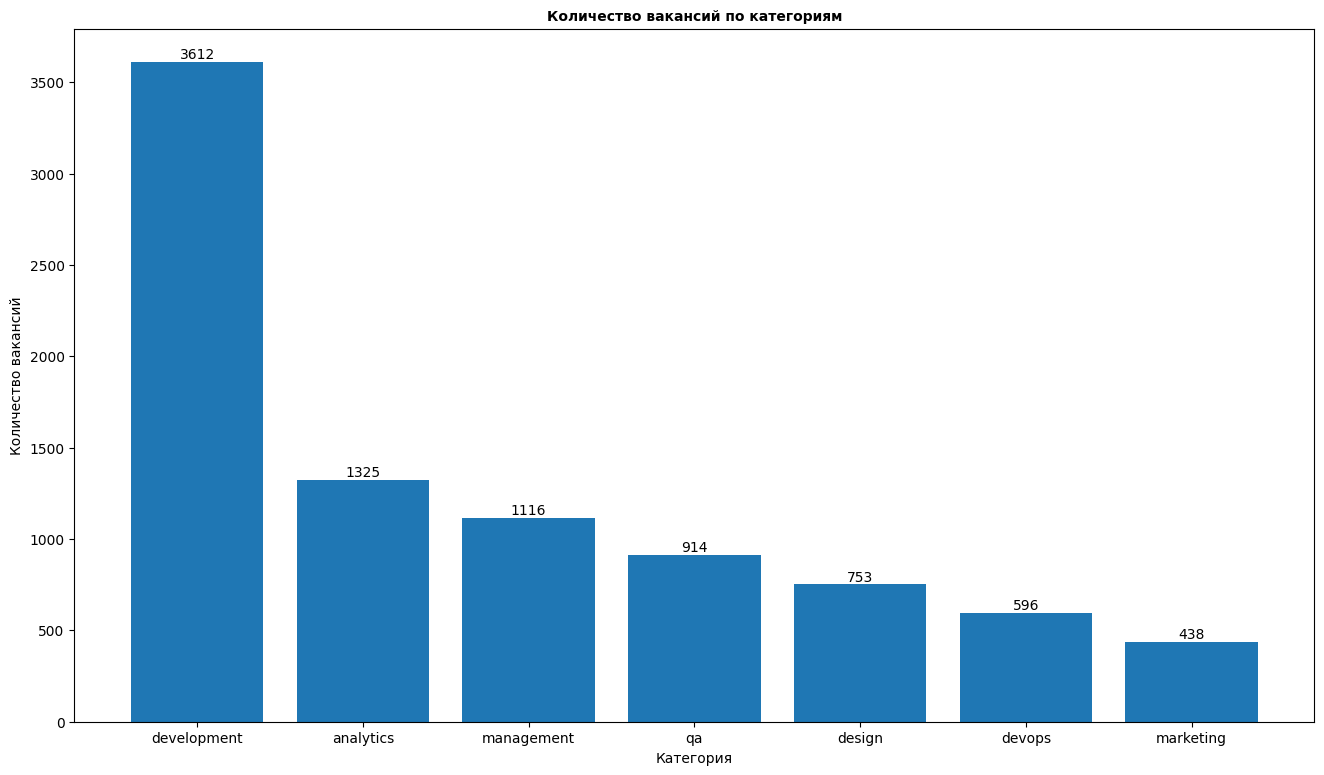

In [58]:
plt.figure(figsize=(16, 9))
categories = data["category"].value_counts()
x = categories.index
y = categories.values
plt.title("Количество вакансий по категориям", fontsize=10, fontweight="bold")
plt.xlabel("Категория")
plt.ylabel("Количество вакансий")
plt.bar_label(plt.bar(x, y))
plt.show()

Заметим, что в категории development больше всего вакансий, тогда посмотрим какие специалисты по грейдам требуются

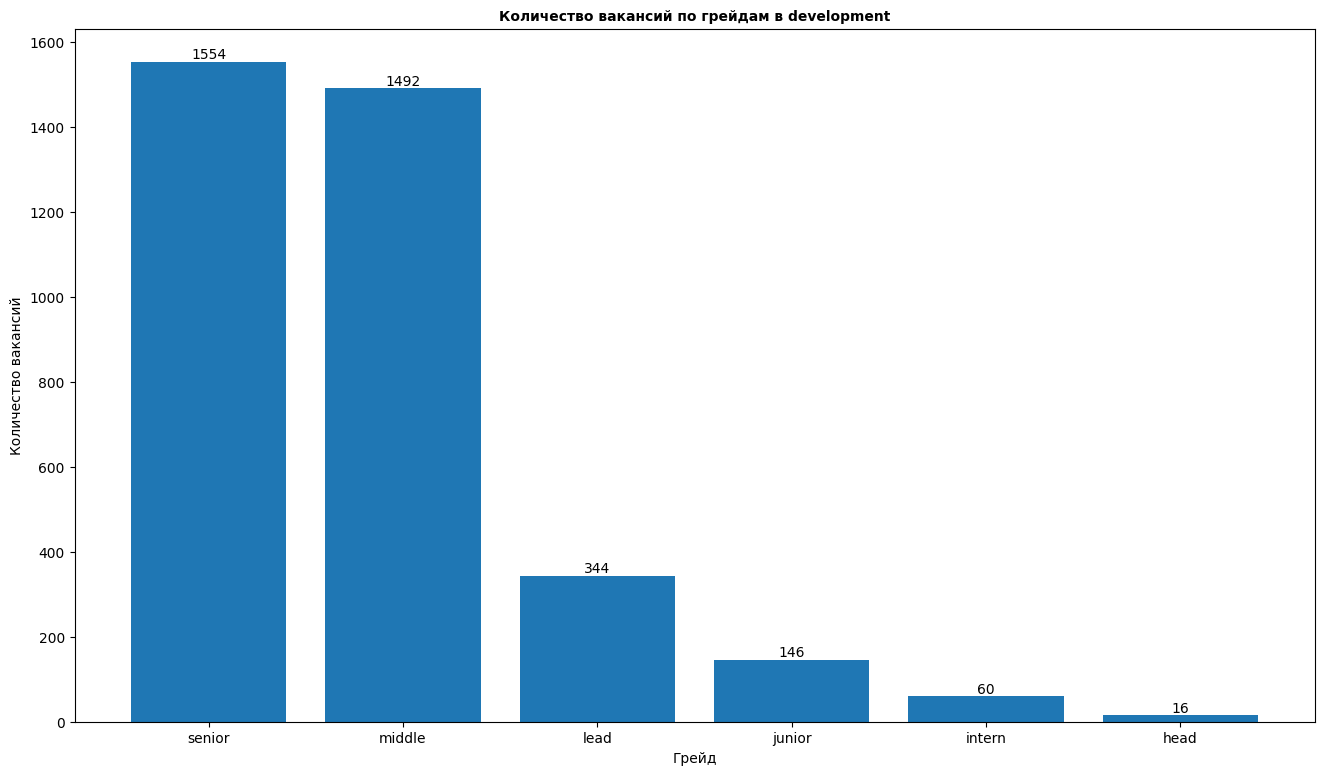

In [59]:
plt.figure(figsize=(16, 9))
devs = data[data["category"] == "development"]
devgrades = devs["level"].value_counts()
x = devgrades.index
y = devgrades.values
plt.title(
    "Количество вакансий по грейдам в development", fontsize=10, fontweight="bold"
)
plt.xlabel("Грейд")
plt.ylabel("Количество вакансий")
plt.bar_label(plt.bar(x, y))
plt.show()

Видим, что большинство работодателей ищут самостоятельных специалистов(senior, middle), поменьше ищут руководителей команд(lead), начинающих специалистов ищут еще меньше (в сумме 206) из 3612 вакансий, что может говорить о том, что в связщи ростом заинтересованности в it в России и в целом по всему миру, очень много специалистов без опыта, имеющих желание устроиться на работу, поэтому из-за огромного количества новичков порог входа повышается и работодатели не сильно хотоят выращивать специалиста из новичка. Грейд head имеет всего лишь 16 вакансий.

Теперь можно посмотреть как меняются зарплаты в development в зависимости от грейда

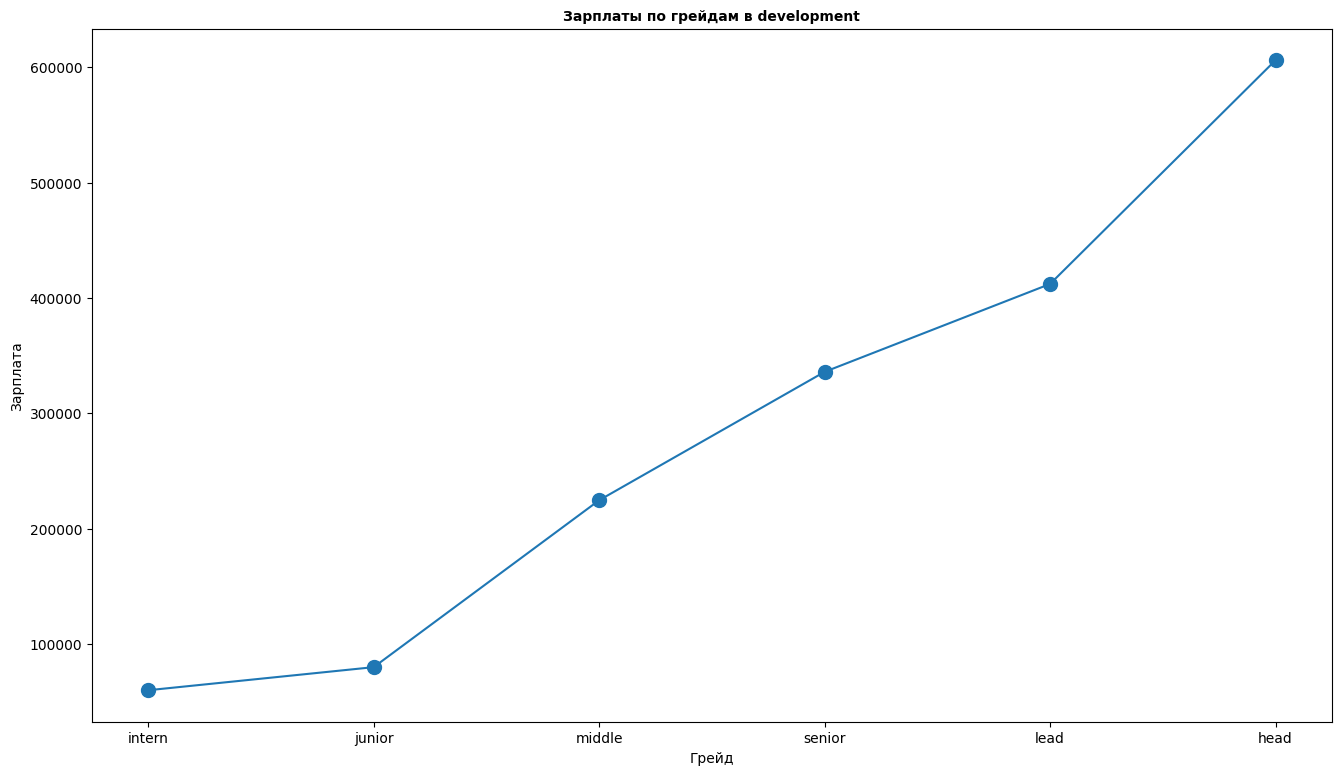

In [60]:
plt.figure(figsize=(16, 9))
devs = data[data["category"] == "development"]
devsalaries = devs.groupby("level")["salary"].median().sort_values()
x = devsalaries.index
y = devsalaries.values
plt.title("Зарплаты по грейдам в development", fontsize=10, fontweight="bold")
plt.xlabel("Грейд")
plt.ylabel("Зарплата")
plt.plot(x, y, marker="o", markersize="10")
plt.show()

В целом видим, что достаточно весомые скачки в зарплате происходят при переходе от начинающего специалиста к самостоятельному(middle) при переходе на руководящую должность, там зарплаты гораздо-гораздо выше.

Можно еще посмотреть какой формат сейчас опережает остальные по зарплатам

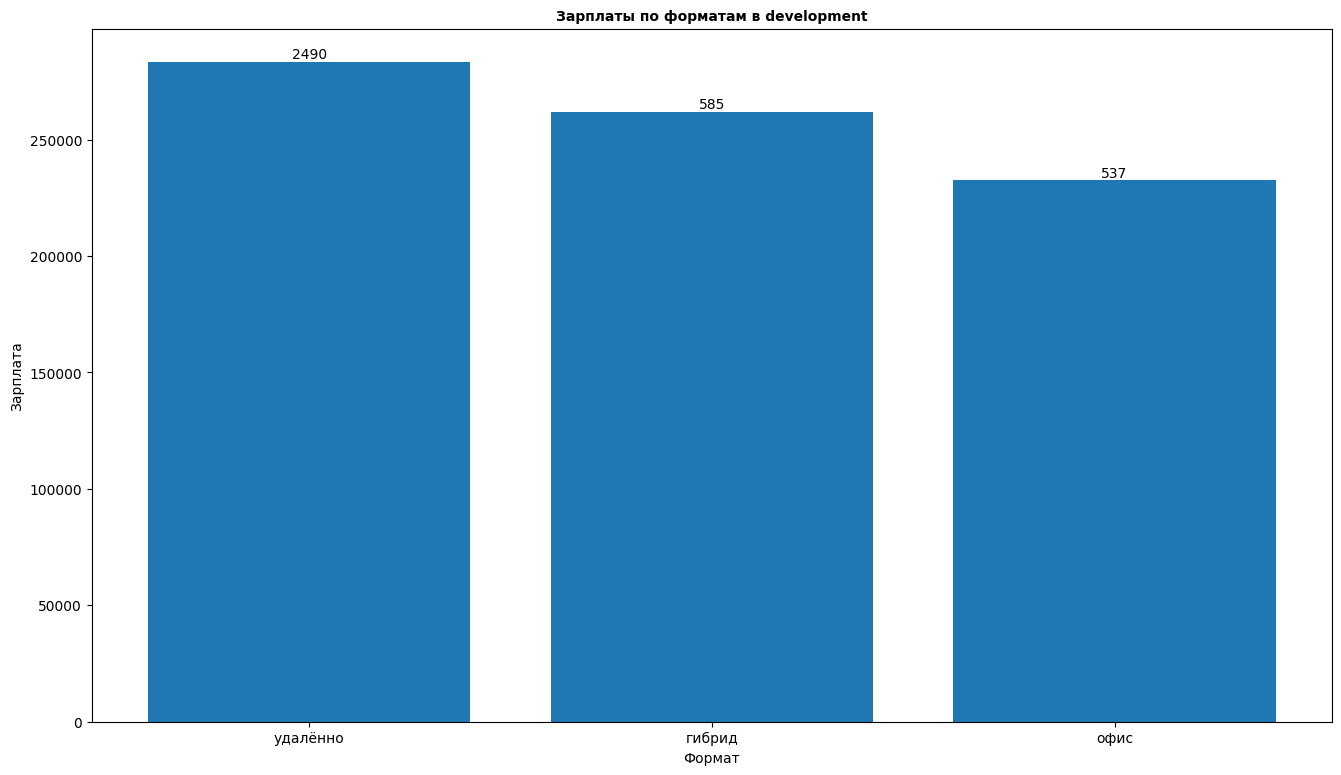

In [61]:
plt.figure(figsize=(16, 9))
devs = data[data["category"] == "development"]
counts = devs["format"].value_counts()
devsalaries = devs.groupby("format")["salary"].median().sort_values(ascending=False)
x = devsalaries.index
y = devsalaries.values
plt.title("Зарплаты по форматам в development", fontsize=10, fontweight="bold")
plt.xlabel("Формат")
plt.ylabel("Зарплата")
plt.bar_label(plt.bar(x, y), labels=counts.values)
plt.show()

Удаленных вакансий для разработчиков очень много, посмотрим теперь как распределены грейды.

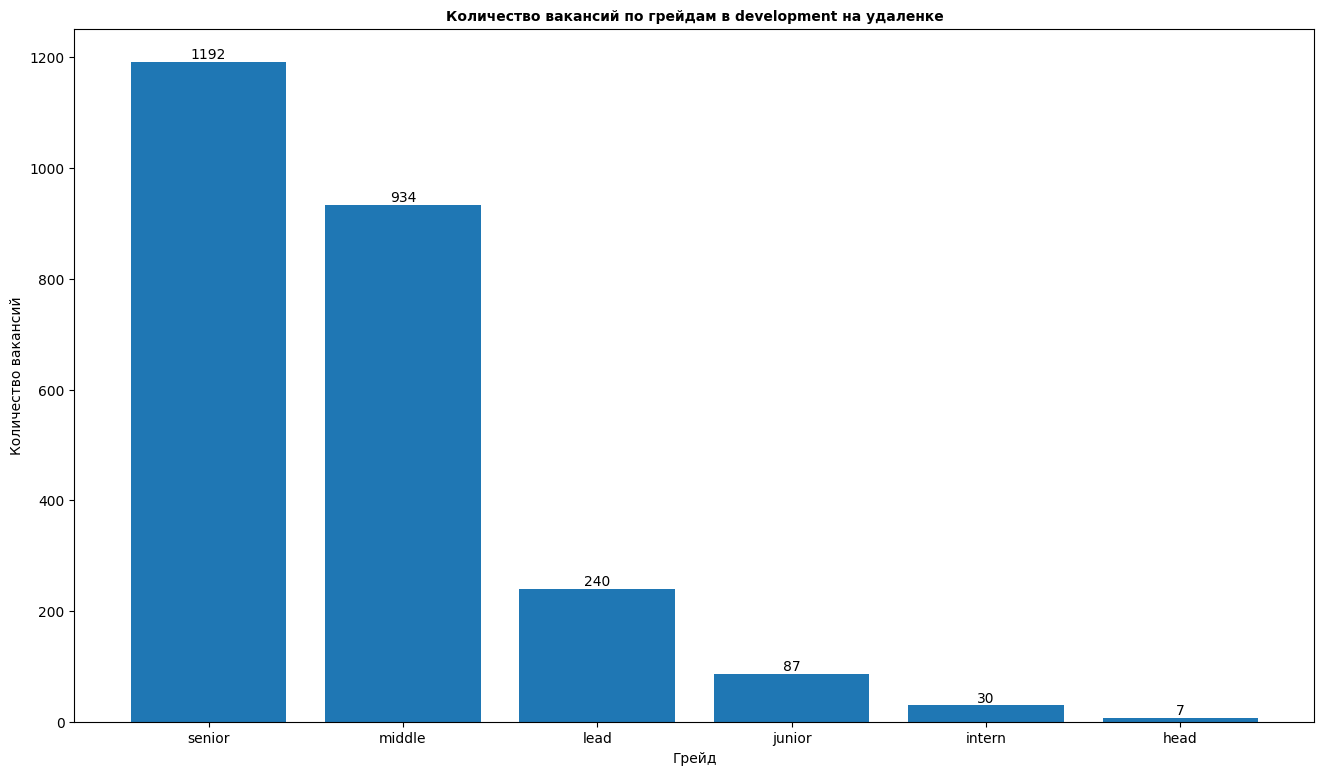

In [62]:
plt.figure(figsize=(16, 9))
devs = data[(data["category"] == "development") & (data["format"] == "удалённо")]
devgrades = devs["level"].value_counts()
x = devgrades.index
y = devgrades.values
plt.title(
    "Количество вакансий по грейдам в development на удаленке",
    fontsize=10,
    fontweight="bold",
)
plt.xlabel("Грейд")
plt.ylabel("Количество вакансий")
plt.bar_label(plt.bar(x, y))
plt.show()

Около 75% всех вакансий принадлежать senior'ам и middle'ам, что говорит о том, что удаленный рынок требует большой автономности от кандидатов.

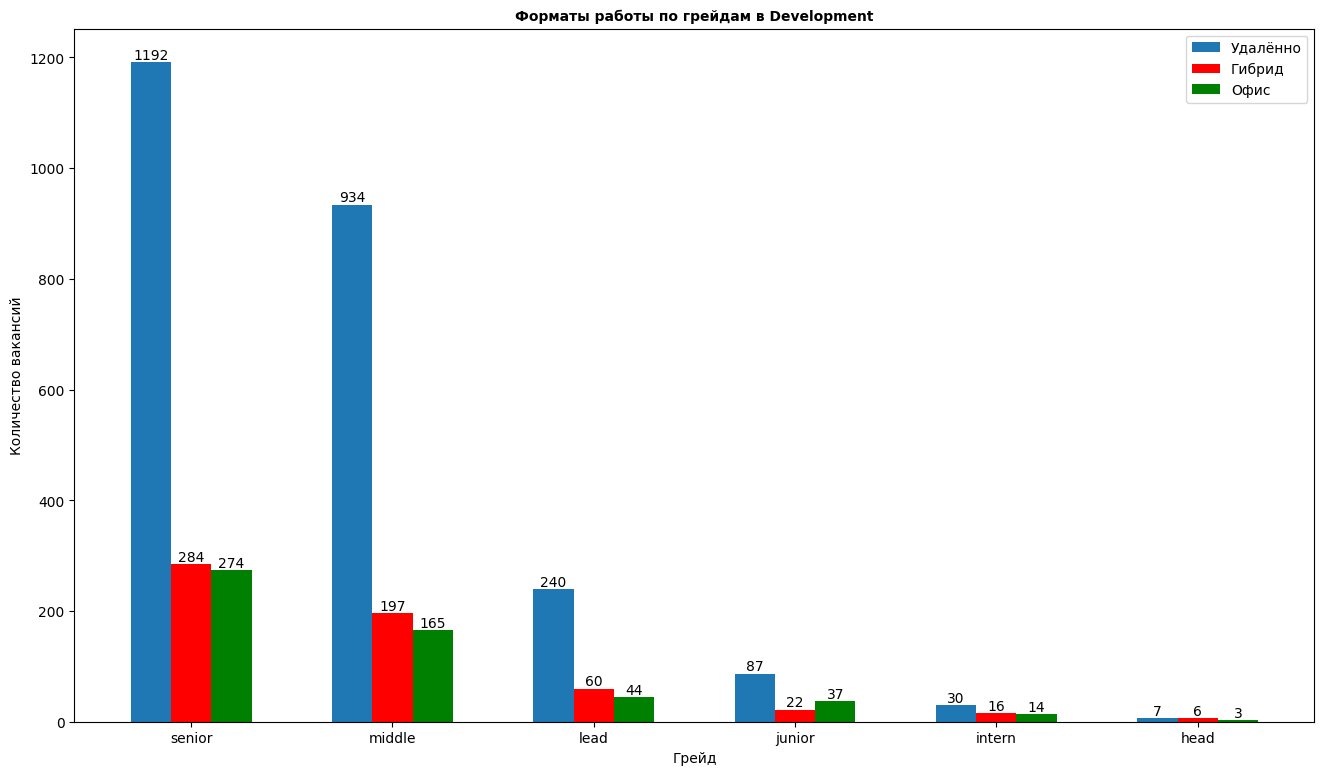

In [63]:
plt.figure(figsize=(16, 9))
devs = data[data["category"] == "development"]
y1 = devs[devs["format"] == "удалённо"]["level"].value_counts()
y2 = devs[devs["format"] == "гибрид"]["level"].value_counts()
y3 = devs[devs["format"] == "офис"]["level"].value_counts()
grades = devs["level"].unique()
x = np.arange(len(grades))
b1 = plt.bar(x - 0.2, y1, width=0.2, label="Удалённо")
b2 = plt.bar(x, y2, width=0.2, label="Гибрид", color="red")
b3 = plt.bar(x + 0.2, y3, width=0.2, label="Офис", color="green")
plt.bar_label(b1)
plt.bar_label(b2)
plt.bar_label(b3)
plt.xticks(x, grades)
plt.title("Форматы работы по грейдам в Development", fontsize=10, fontweight="bold")
plt.xlabel("Грейд")
plt.ylabel("Количество вакансий")
plt.legend()
plt.show()

В целом прослеживается тенденция на удаленный формат работы на всех грейдах.

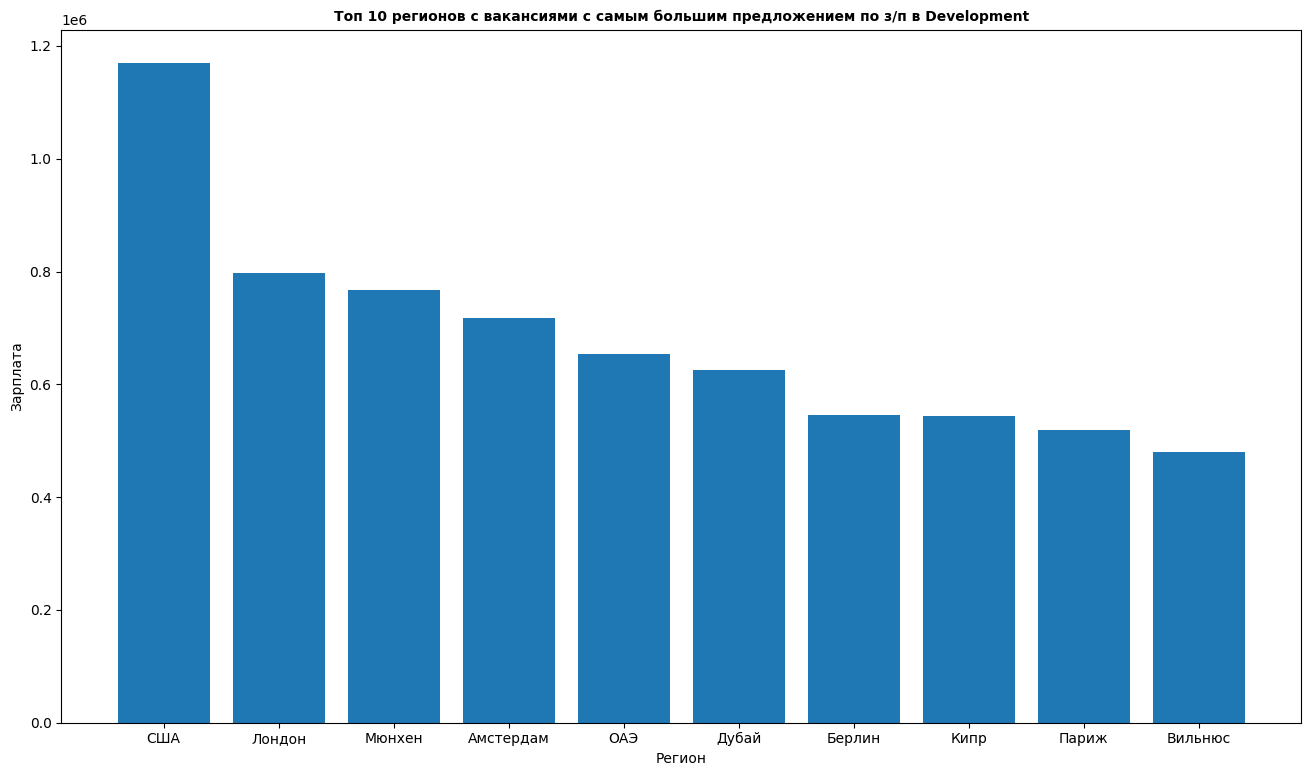

In [64]:
plt.figure(figsize=(16, 9))
devs = data[data["category"] == "development"]
counts = devs["city/country"].value_counts()
regions = (
    devs.groupby("city/country")["salary"]
    .median()
    .sort_values(ascending=False)
    .head(10)
)
x = regions.index
y = regions.values
plt.title(
    "Топ 10 регионов с вакансиями с самым большим предложением по з/п в Development",
    fontsize=10,
    fontweight="bold",
)
plt.xlabel("Регион")
plt.ylabel("Зарплата")
plt.bar(x, y)
plt.show()

Вакансии с самыми большими зарплатами предлагают компании из Европы и США

#### Анализ взаимосвязей со skills

Оценим, как распределено количество требуемых инструментов для различных вакансий. Для этого создадим дополнительный признак - `skills_num`.

In [65]:
data["skills_num"] = data["skills"].apply(lambda x: len(x))
skills_length_grouped = data["skills_num"].value_counts()
skills_length_grouped

skills_num
10    1353
15    1199
12    1198
14    1193
13     981
11     959
9      443
8      347
7      246
16     238
6      176
5      112
4       65
17      61
0       55
20      39
18      29
3       27
19      18
2       11
1        4
Name: count, dtype: int64

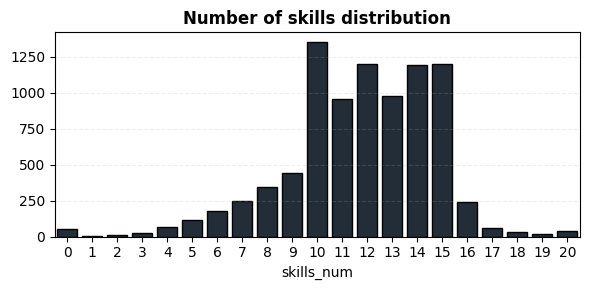

In [66]:
fig, ax = plt.subplots(figsize=(6, 3))

sns.barplot(
    x=skills_length_grouped.index,
    y=skills_length_grouped.values,
    color=palette[0],
    edgecolor="black",
)
ax.grid(axis="y", linestyle="--", alpha=0.2)
ax.set_title("Number of skills distribution", fontweight="bold")
plt.tight_layout()

Большинство вакансий требуют от 10 до 15 навыков. При этом наблюдается небольшое число вакансий, для которых навыки не требуются - скорее всего карточка не заполнена

Посмотрим на распределение количества необходимых навыков относительно различных направлений:

In [67]:
data_grouped = data.groupby("category")["skills_num"].mean()
data_grouped

category
analytics      11.633962
design         10.543161
development    11.922481
devops         13.572148
management     11.214158
marketing      10.518265
qa             12.278993
Name: skills_num, dtype: float64

Посмотрим на зависимость количества скиллов от грейда специалиста:

In [68]:
level_groupped = data.groupby("level")["skills_num"].mean()
level_groupped

level
head      11.333333
intern     9.232558
junior     9.871795
lead      11.945312
middle    11.590415
senior    12.315858
Name: skills_num, dtype: float64

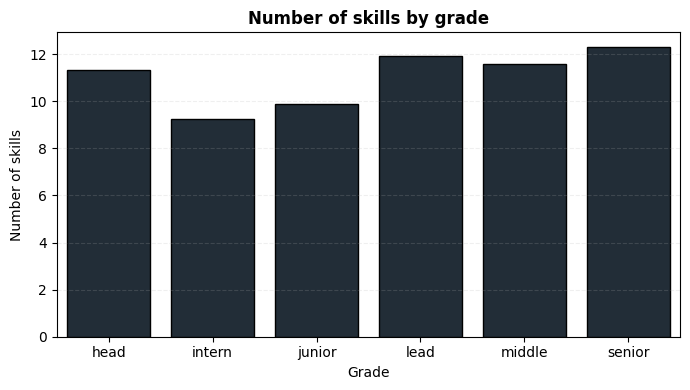

In [69]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(data=level_groupped, color=palette[0], edgecolor="black")

ax.set_xlabel("Grade")
ax.set_ylabel("Number of skills")
ax.grid(axis="y", linestyle="--", alpha=0.2)
ax.set_title("Number of skills by grade", fontweight="bold")
plt.tight_layout()

Посмотрим, какие навыки требуются в самых распространенных вакансиях:

In [70]:
top_4_vac = data["title"].value_counts().iloc[1:5].index
print(f"Топ 3 вакансий: {top_4_vac}")

Топ 3 вакансий: Index(['product manager', 'системный аналитик', 'project manager',
       'devops engineer'],
      dtype='str', name='title')


Для каждой из вакансий выберем наиболее востребованные для неё скиллы:

In [71]:
top_n = 5

skill_title = pd.merge(left=data, right=data_skills, on="id")[["title", "skill"]]
top4_exp = skill_title[skill_title["title"].isin(top_4_vac)]
top4_exp = top4_exp.groupby(["title", "skill"]).size().reset_index(name="skills_num")
top4_exp = top4_exp.sort_values(["title", "skills_num"], ascending=False)

data_skills_topn = []
for vac in top_4_vac:
    data_skills_topn.append(top4_exp[top4_exp["title"] == vac].head(top_n))
data_skills_topn

[                title               skill  skills_num
 848   product manager  product management         107
 907   product manager             roadmap          50
 849   product manager     product manager          45
 1064  product manager           аналитика          44
 454   product manager                  ai          42,
                    title       skill  skills_num
 2245  системный аналитик        bpmn         109
 2498  системный аналитик         sql         105
 2532  системный аналитик         uml          95
 2461  системный аналитик        rest          68
 2267  системный аналитик  confluence          61,
                 title                 skill  skills_num
 1709  project manager    project management         101
 1379  project manager                 agile          65
 1599  project manager                  jira          57
 1761  project manager                 scrum          48
 2169  project manager  управление проектами          39,
                title    

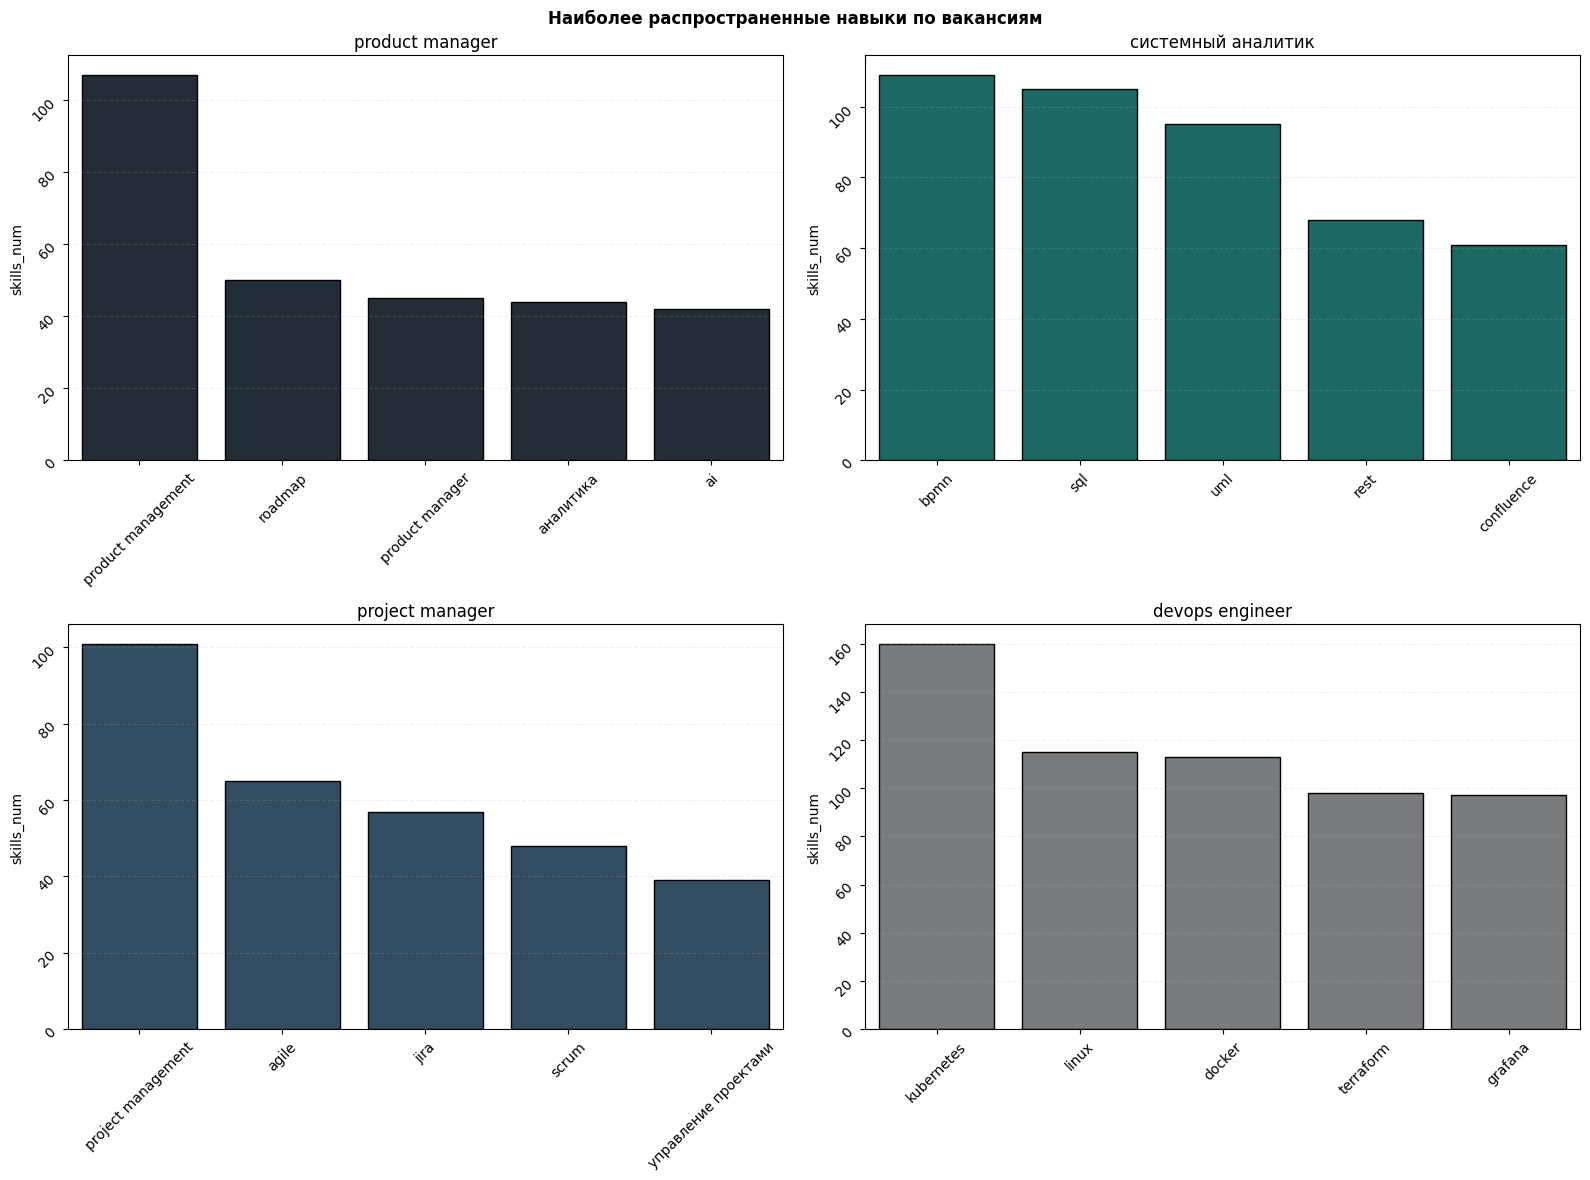

In [72]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(16, 12))
fig.suptitle("Наиболее распространенные навыки по вакансиям", fontweight="bold")
for i in range(4):
    sns.barplot(
        data=data_skills_topn[i],
        x="skill",
        y="skills_num",
        color=palette[i],
        edgecolor="black",
        ax=axes[i // 2][i % 2],
    )
    axes[i // 2][i % 2].grid(axis="y", linestyle="--", alpha=0.2)
    axes[i // 2][i % 2].set_title(top_4_vac[i])
    axes[i // 2][i % 2].tick_params(labelrotation=45)
    axes[i // 2][i % 2].set_xlabel("")
plt.tight_layout()

Использован метод [`tick_params`](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.tick_params.html) из библиотеки matplotlib. Необзодимость обусловлена использование объектно ориентированного подхода при оформлении графиков.

Использован метод [`tight_layout`](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.tight_layout.html) из библиотеки matplotlib. Позволяет улучшить читаемость картинки путем изменения отступов между графиками.

In [73]:
data_skills.isna().sum()

id        0
skill    55
dtype: int64

Количество пропущенных не поменялось, поэтому удалим их из рассмотрения

In [74]:
data_skills = data_skills.dropna()

Дубликаты и кардинальность: 

In [75]:
print(f"Наличе дубликатов:              {data_skills.duplicated().any()}")
print(f"Количество уникальных значений: {data_skills['skill'].nunique()}")

Наличе дубликатов:              False
Количество уникальных значений: 10409


Определим самые часто-встречающиеся навыки:

In [76]:
top_n = 15
skill_stats = data_skills["skill"].value_counts().head(top_n).sort_values()
skill_stats

skill
ai             696
redis          701
аналитика      729
jira           753
typescript     797
linux          850
ci/cd          921
api           1048
kafka         1072
kubernetes    1170
git           1291
docker        1512
postgresql    1519
python        2091
sql           2289
Name: count, dtype: int64

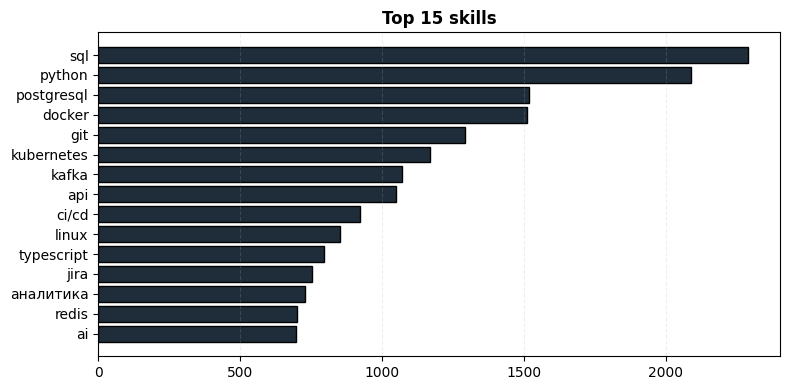

In [77]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.barh(
    y=skill_stats.index, width=skill_stats.values, edgecolor="black", color=palette[0]
)

ax.grid(axis="x", linestyle="--", alpha=0.2)
ax.set_title(f"Top {top_n} skills", fontweight="bold")
plt.tight_layout()

Попробуем понять, за какой навык платят наибольшую зарплату. Так как в списке навыков есть редко встречающиеся и слабо интерпретируемые навыки, рассмотрим топ 600 самых распространенных навыков. 

In [78]:
top_skills = data_skills["skill"].value_counts().head(600).index
top_skills

Index(['sql', 'python', 'postgresql', 'docker', 'git', 'kubernetes', 'kafka',
       'api', 'ci/cd', 'linux',
       ...
       'mobile design', 'антифрод', 'vertica', 'llamaindex',
       'банковские продукты', 'digital marketing', 'hive', 'state management',
       'виртуализация', 'отчётность'],
      dtype='str', name='skill', length=600)

In [79]:
top_exp = data_skills[data_skills["skill"].isin(top_skills)]
top_exp

,id,skill
0,36700,api
0,36700,sdlc
0,36700,web testing
0,36700,manual testing
0,36700,qa
...,...,...
8753,24786,gitlab
8753,24786,bash
8753,24786,postgresql
8753,24786,jenkins


In [80]:
skill_salary = pd.merge(left=top_exp, right=data, on="id")[["skill", "salary"]]
skill_salary_grouped = skill_salary.groupby("skill")["salary"].agg(
    ["mean", "median", "count"]
)
skill_salary_grouped = skill_salary_grouped.sort_values(
    ["median", "mean"], ascending=False
)
skill_salary_grouped_top = skill_salary_grouped.head(5)
skill_salary_grouped_top

,mean,median,count
skill,,,
distributed systems,433733.820896,441800.0,67
defi,460690.476190,426400.0,42
leadership,440526.567568,420000.0,37
scalability,449998.406250,417500.0,32
cloud,401100.000000,406650.0,40


<Axes: xlabel='skill'>

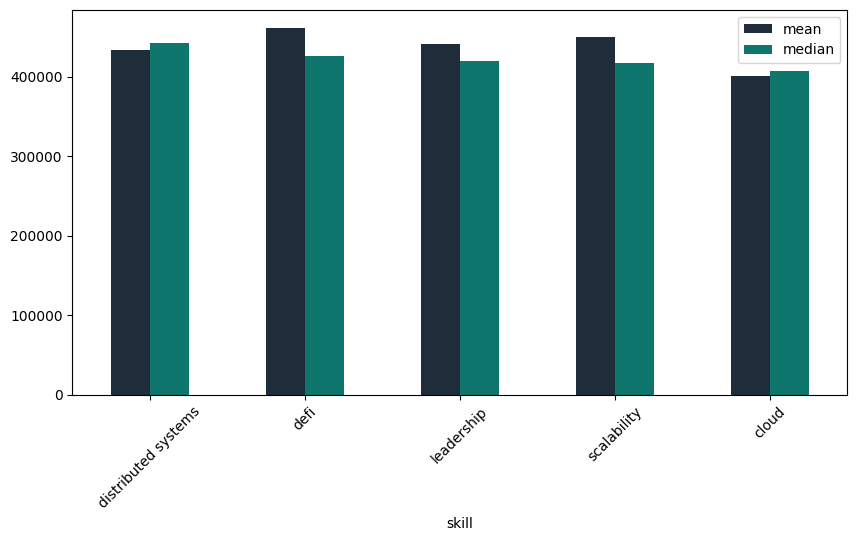

In [81]:
skill_salary_grouped_top[["mean", "median"]].plot(
    kind="bar", figsize=(10, 5), color=palette, rot=45
)

На основе документации [`plot`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html).